In [12]:
import pandas as pd

optimal = {'la01': 666, 'la11': 1222,
           'la02': 655, 'la12': 1039,
           'la03': 597, 'la13': 1150,
           'la04': 590, 'la14': 1292,
           'la05': 593, 'la15': 1207,
           'la06': 926, 'la16': 945,
           'la07': 890, 'la17': 784,
           'la08': 863, 'la18': 848,
           'la09': 951, 'la19': 842,
           'la10': 958, 'la20': 902,
           }
# CSV 파일 불러오기
df = pd.read_csv("Tabu_result.csv")  # 실제 파일 경로로 바꿔줘야 함

In [13]:
df

,Instance,Seed,Termination,RUBI
0,la01,0,6,False
1,la01,1,111,False
2,la01,2,69,False
3,la01,3,122,False
4,la01,4,0,False
...,...,...,...,...
339,la17,9,0,True
340,la18,0,0,False
341,la18,1,0,False
342,la18,2,0,False


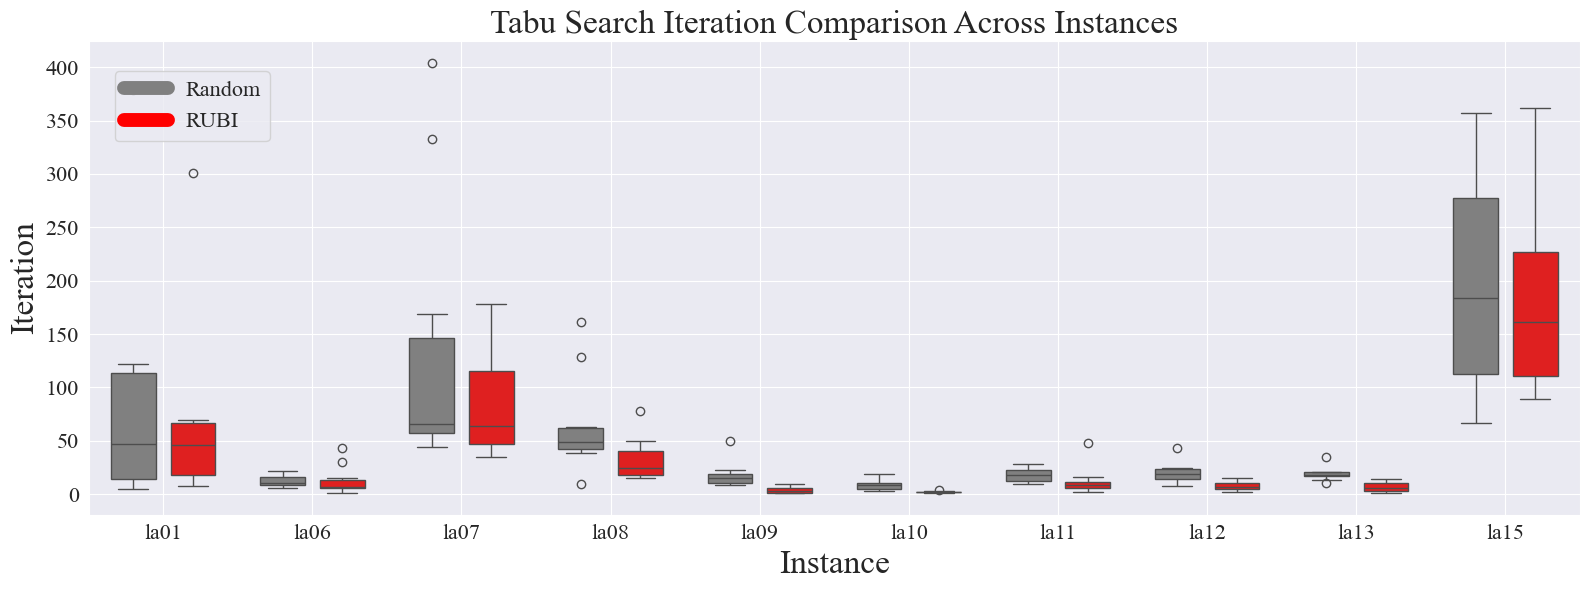

In [63]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams.update({'font.size': 14})
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
# CSV 파일 불러오기
problem_values = [f"la{str(i).zfill(2)}" for i in range(1, 18)]

# CSV 파일 불러오기
df = pd.read_csv("Tabu_result.csv")

fig, ax = plt.subplots(figsize=(16, 6))  # 그래프가 넓게 펼쳐지도록 설정
plot_data = []
for idx, row in df.iterrows():
    if row['Termination'] !=0:
        plot_data.append({
                            
                            'Instance': row['Instance'],
                            'Termination': row['Termination'],
                            'Hue': row['RUBI']
                        })
plot_df = pd.DataFrame(plot_data)

# 색상 매핑 (False=gray, True=red)
palette = {False: 'gray', True: 'red'}
# sns.boxplot(data=df_random, x='Instance', y='Termination', hue='RUBI',widths=0.3)
sns.boxplot(data=plot_df, x='Instance', y='Termination', hue ='Hue', palette=palette, widths=0.3)
    
ax.set_ylabel('Iteration')
ax.set_title('Tabu Search Iteration Comparison Across Instances')

# 범례 추가
custom_lines = [
    plt.Line2D([0], [0], color='gray', lw=10),
    plt.Line2D([0], [0], color='red', lw=10)
]
ax.legend(custom_lines, ['Random', 'RUBI'], bbox_to_anchor=(0.01, 0.96), loc='upper left')

plt.tight_layout()
plt.grid(True)
plt.savefig('Comparison.png')

In [2]:

# Initialization 값들
init_values = ['SGA_BM','SGA_BRT','RUBI_BM', 'RUBI_BRT']
problem_values = [f"la{str(i).zfill(2)}" for i in range(1, 21)]

# 결과를 담을 DataFrame
result_matrix = pd.DataFrame(index=problem_values, columns=init_values)

# 각 Problem-Initialization 조합에 대해 seed 개수 확인
for problem in problem_values:
    for init in [0, 100]:
        subset = df[(df['Problem'] == problem) & (df['Initialization'] == init)]
        problem = subset['Problem'].unique()[0]
        optimal_set = subset[subset['Best Makespan'] == optimal[problem]]
        if optimal_set.shape[0] !=0:
            avg_optimal = round(optimal_set['Best Reached Time'].mean(),3)
        else:
            avg_optimal = None
        # seed_count = subset['Seed'].nunique()
        if init == 0:
            result_matrix.loc[problem, "SGA_BM"] = subset['Best Makespan'].min()
            result_matrix.loc[problem, "SGA_BRT"] = avg_optimal
        elif init == 100:
            result_matrix.loc[problem, "RUBI_BM"] = subset['Best Makespan'].min()
            result_matrix.loc[problem, "RUBI_BRT"] = avg_optimal


In [3]:
result_matrix

,SGA_BM,SGA_BRT,RUBI_BM,RUBI_BRT
la01,666,121.7,666,169.877
la02,655,298.386,659,None
la03,617,None,617,None
la04,598,None,598,None
la05,593,13.781,593,0.344
la06,926,120.83,926,15.99
la07,890,372.541,890,348.806
la08,863,175.49,863,131.907
la09,951,120.511,951,2.823
la10,958,55.078,958,0.462


In [ ]:

# CSV 파일 불러오기
df = pd.read_csv("result_250114.csv")  # 실제 파일 경로로 바꿔줘야 함

# Initialization 값들
init_values = ['SGA_BM','SGA_BRT','RUBI_BM', 'RUBI_BRT']
problem_values = [f"la{str(i).zfill(2)}" for i in range(1, 21)]

# 결과를 담을 DataFrame
result_matrix = pd.DataFrame(index=problem_values, columns=init_values)

# 각 Problem-Initialization 조합에 대해 seed 개수 확인
for problem in problem_values:
    for init in [0, 100]:
        subset = df[(df['Problem'] == problem) & (df['Initialization'] == init)]
        problem = subset['Problem'].unique()[0]
        optimal_set = subset[subset['Best Makespan'] == optimal[problem]]
        if optimal_set.shape[0] !=0:
            pass
            # TODO : optimal_set['Best Reached Time']의 Boxplot 표시 (Xtick : problem)
            # if init == 0: blue, legend = 'Stardard GA'
            # if init == 100: red, legend = 'RUBI GA'
        else:
            pass


The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


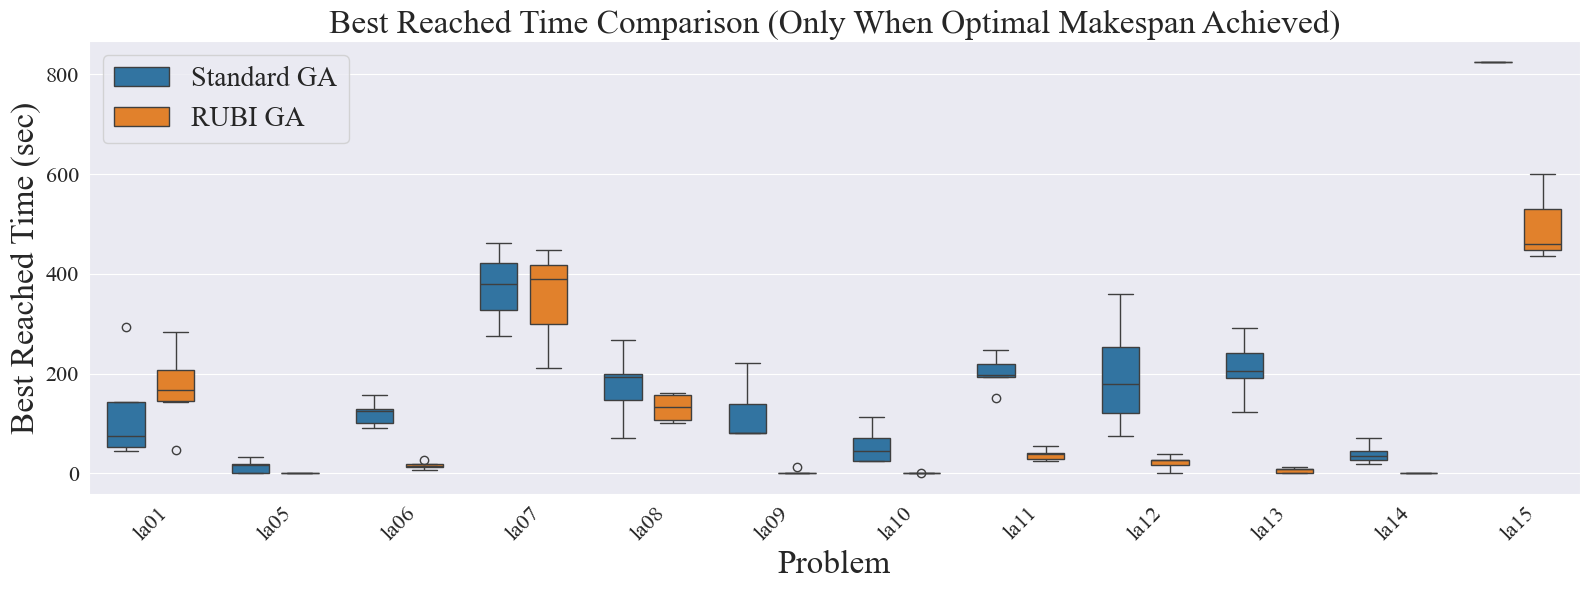

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
SMALL_SIZE = 16
MEDIUM_SIZE = 20
BIGGER_SIZE = 24

plt.rcParams['font.family'] = 'Times New Roman'
# plt.rcParams.update({'font.size': 14})
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=MEDIUM_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title
# CSV 파일 불러오기
df = pd.read_csv("result_250114.csv")  # 실제 파일 경로로 수정 필요

# 문제 리스트 및 컬럼 초기화
init_values = ['SGA_BM', 'SGA_BRT', 'RUBI_BM', 'RUBI_BRT']
problem_values = [f"la{str(i).zfill(2)}" for i in range(1, 21)]

# 가정: optimal 값이 dictionary로 제공됨
# 예: optimal = {"la01": 666, "la02": 655, ...}
# 만약 없다면 파일에서 직접 계산하거나 수동으로 제공 필요
optimal = {
    "la01": 666, "la02": 655, "la03": 597, "la04": 590, "la05": 593,
    "la06": 926, "la07": 890, "la08": 863, "la09": 951, "la10": 958,
    "la11": 1222, "la12": 1039, "la13": 1150, "la14": 1292, "la15": 1207,
    "la16": 945, "la17": 784, "la18": 848, "la19": 842, "la20": 902
}

# 시각화를 위한 리스트 저장
plot_data = []

for problem in problem_values:
    for init in [0, 100]:  # 0: Standard GA, 100: RUBI
        label = 'Standard GA' if init == 0 else 'RUBI GA'
        subset = df[(df['Problem'] == problem) & (df['Initialization'] == init)]
        
        # 해당 문제에서 optimal makespan에 도달한 subset만 필터링
        optimal_set = subset[subset['Best Makespan'] == optimal[problem]]
        if problem != "la02":
            if not optimal_set.empty:
                for t in optimal_set['Best Reached Time']:
                    plot_data.append({
                        'Problem': problem,
                        'Time': t,
                        'Method': label
                    })

# DataFrame으로 변환
plot_df = pd.DataFrame(plot_data)

# Plot
plt.figure(figsize=(16, 6))
sns.boxplot(data=plot_df, x='Problem', y='Time', hue='Method', widths=0.3)

"""

            sns.boxplot(x='Mode', y=metric, data=subset, ax=axes[x[i],y[i]], 
                        order=modes, widths=0.5, patch_artist=True, 
                        boxprops=dict(facecolor=colors[j]),
                        medianprops=dict(color='k'))
"""
plt.title("Best Reached Time Comparison (Only When Optimal Makespan Achieved)")
plt.ylabel("Best Reached Time (sec)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig('Comparison.eps')
# plt.savefig('Comparison.png',dpi=300)
# plt.show()
